In [1]:
# Importing libraries that may be needed for this project
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

In [2]:
# Reading the .csv file into a dataframe
df = pd.read_csv("enhanced_box_office_data(2000-2024)u.csv")

In [3]:
# Checking the basic info of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Rank                  5000 non-null   int64  
 1   Release Group         5000 non-null   object 
 2   $Worldwide            5000 non-null   float64
 3   $Domestic             5000 non-null   float64
 4   Domestic %            5000 non-null   float64
 5   $Foreign              5000 non-null   float64
 6   Foreign %             5000 non-null   float64
 7   Year                  5000 non-null   int64  
 8   Genres                4822 non-null   object 
 9   Rating                4830 non-null   object 
 10  Vote_Count            4830 non-null   float64
 11  Original_Language     4830 non-null   object 
 12  Production_Countries  4800 non-null   object 
dtypes: float64(6), int64(2), object(5)
memory usage: 507.9+ KB


In [4]:
# Checking the information of the numeric columns
df.describe()

,Rank,$Worldwide,$Domestic,Domestic %,$Foreign,Foreign %,Year,Vote_Count
count,5000.00000,5.000000e+03,5.000000e+03,5000.000000,5.000000e+03,5000.000000,5000.000000,4830.000000
mean,100.50000,1.192137e+08,4.472523e+07,35.740620,7.448809e+07,64.256640,2012.000000,2531.585921
std,57.74008,2.005243e+08,7.727026e+07,30.656992,1.334932e+08,30.654531,7.211824,3946.272827
min,1.00000,1.666028e+06,0.000000e+00,0.000000,0.000000e+00,0.000000,2000.000000,0.000000
25%,50.75000,2.466220e+07,9.275150e+04,0.200000,1.371034e+07,42.200000,2006.000000,205.250000
50%,100.50000,4.844658e+07,1.798421e+07,37.050000,3.019444e+07,62.950000,2012.000000,1035.500000
75%,150.25000,1.197588e+08,5.386847e+07,57.800000,7.211578e+07,99.800000,2018.000000,3065.000000
max,200.00000,2.799439e+09,9.366622e+08,100.000000,1.993811e+09,100.000000,2024.000000,36753.000000


In [5]:
# A quick glance at the dataframe
df.head()

,Rank,Release Group,$Worldwide,$Domestic,Domestic %,$Foreign,Foreign %,Year,Genres,Rating,Vote_Count,Original_Language,Production_Countries
0,1,Mission: Impossible II,546388108.0,215409889.0,39.4,330978219.0,60.6,2000,"Adventure, Action, Thriller",6.126/10,6741.0,en,United States of America
1,2,Gladiator,460583960.0,187705427.0,40.8,272878533.0,59.2,2000,"Action, Drama, Adventure",8.217/10,19032.0,en,"United Kingdom, United States of America"
2,3,Cast Away,429632142.0,233632142.0,54.4,196000000.0,45.6,2000,"Adventure, Drama",7.663/10,11403.0,en,United States of America
3,4,What Women Want,374111707.0,182811707.0,48.9,191300000.0,51.1,2000,"Comedy, Romance",6.45/10,3944.0,en,"United Kingdom, United States of America"
4,5,Dinosaur,349822765.0,137748063.0,39.4,212074702.0,60.6,2000,"Animation, Family, Adventure",6.544/10,2530.0,en,United States of America


In [11]:
# Which movie was the highest grossing one in these years worldwide?
df.loc[df["$Worldwide"].idxmax()]

Rank                                                     1
Release Group                            Avengers: Endgame
$Worldwide                                    2799439100.0
$Domestic                                      858373000.0
Domestic %                                            30.7
$Foreign                                      1941066100.0
Foreign %                                             69.3
Year                                                  2019
Genres                  Adventure, Science Fiction, Action
Rating                                            8.246/10
Vote_Count                                         25780.0
Original_Language                                       en
Production_Countries              United States of America
Name: 3800, dtype: object

In [12]:
# Which movie was the highest grossing one in these years in North America?
df.loc[df["$Domestic"].idxmax()]

Rank                                                             1
Release Group           Star Wars: Episode VII - The Force Awakens
$Worldwide                                            2068223624.0
$Domestic                                              936662225.0
Domestic %                                                    45.3
$Foreign                                              1131561399.0
Foreign %                                                     54.7
Year                                                          2015
Genres                          Adventure, Action, Science Fiction
Rating                                                    7.271/10
Vote_Count                                                 19411.0
Original_Language                                               en
Production_Countries                      United States of America
Name: 3000, dtype: object

In [13]:
# Which movie was the highest grossing one in these years outside of North America?
df.loc[df["$Foreign"].idxmax()]

Rank                                                              1
Release Group                                                Avatar
$Worldwide                                             2743577587.0
$Domestic                                               749766139.0
Domestic %                                                     27.3
$Foreign                                               1993811448.0
Foreign %                                                      72.7
Year                                                           2009
Genres                  Action, Adventure, Fantasy, Science Fiction
Rating                                                     7.583/10
Vote_Count                                                  31654.0
Original_Language                                                en
Production_Countries       United States of America, United Kingdom
Name: 1800, dtype: object

In [14]:
# What was the average box office of a movie worldwide between 2000 and 2024?
df["$Worldwide"].mean()

np.float64(119213693.2098)

In [15]:
# What was the average box office of a movie in North America between 2000 and 2024?

df["$Domestic"].mean()

np.float64(44725232.97)

In [16]:
# What was the average box office of a movie outside of North America between 2000 and 2024?

df["$Foreign"].mean()

np.float64(74488092.7352)

In [30]:
# Now let's 
df_worldwide_mean = df.groupby("Year")["$Worldwide"].mean()
df_worldwide_mean = pd.DataFrame(df_worldwide_mean).reset_index()
df_worldwide_mean

,Year,$Worldwide
0,2000,6.955243e+07
1,2001,8.076565e+07
2,2002,8.885957e+07
3,2003,9.371740e+07
4,2004,9.729675e+07
5,2005,9.448475e+07
6,2006,9.959327e+07
7,2007,1.115311e+08
8,2008,1.162683e+08
9,2009,1.284723e+08


In [31]:
df_worldwide_sum = df.groupby("Year")["$Worldwide"].sum()
df_worldwide_sum = pd.DataFrame(df_worldwide_sum).reset_index()
df_worldwide_sum

,Year,$Worldwide
0,2000,1.391049e+10
1,2001,1.615313e+10
2,2002,1.777191e+10
3,2003,1.874348e+10
4,2004,1.945935e+10
5,2005,1.889695e+10
6,2006,1.991865e+10
7,2007,2.230623e+10
8,2008,2.325366e+10
9,2009,2.569447e+10


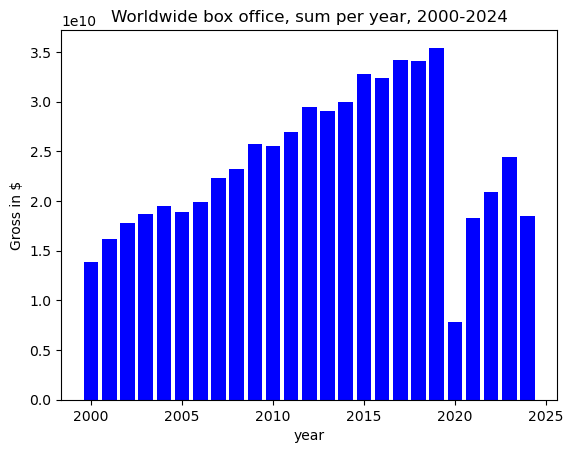

In [33]:
plt.bar(df_worldwide_sum["Year"],df_worldwide_sum["$Worldwide"],color="b")
plt.xlabel("year")
plt.ylabel("Gross in $")
plt.title("Worldwide box office, sum per year, 2000-2024")
plt.show()
